# Phase 4 — Data Drift Detection

**Goal:** Detect and visualize data drift between training (reference) and incoming distributions using KS Test and Wasserstein Distance.

## Scenarios
| Scenario | Description | Expected Drift |
|---|---|---|
| `baseline` | Test split vs train split (same source) | Low |
| `noise` | Gaussian noise added to incoming features | High |
| `speaker_split` | Male actors (ref) vs female actors (incoming) | Medium |

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
FEATURES_DIR = Path('../data/features')
DRIFT_DIR    = Path('../data/drift_reports')
EXPORTS_DIR  = Path('../data/monitoring_exports')

from src.drift_detection import run_drift_detection

results = run_drift_detection(
    features_dir='../data/features',
    drift_dir='../data/drift_reports',
    exports_dir='../data/monitoring_exports',
    config_path='../configs/config.yaml',
    noise_std=1.0,
)

# Or from terminal:
# python src/drift_detection.py
# python src/drift_detection.py --noise_std 2.0

In [2]:
from src.drift_detection import run_drift_detection

results = run_drift_detection(
    features_dir='../data/features',
    drift_dir='../data/drift_reports',
    exports_dir='../data/monitoring_exports',
    noise_std=1.0,
)

# Or from terminal:
# python src/drift_detection.py
# python src/drift_detection.py --noise_std 2.0


──────────────────────────────────────────────────
Scenario: baseline
  Reference : (1152, 240)   Incoming: (288, 240)
  KS drift    : 4/240 features (1.7%)
  Wasserstein : 75/240 features (31.2%)
  Mean KS stat: 0.0532   Mean W-dist: 0.1208

──────────────────────────────────────────────────
Scenario: noise
  Reference : (1152, 240)   Incoming: (288, 240)
  KS drift    : 169/240 features (70.4%)
  Wasserstein : 240/240 features (100.0%)
  Mean KS stat: 0.3039   Mean W-dist: 0.6164

──────────────────────────────────────────────────
Scenario: speaker_split
  Reference : (720, 240)   Incoming: (720, 240)
  KS drift    : 232/240 features (96.7%)
  Wasserstein : 138/240 features (57.5%)
  Mean KS stat: 0.2784   Mean W-dist: 0.9726

Drift scores saved to ..\data\monitoring_exports\drift_scores.csv


## 2. Drift Score Comparison Across Scenarios

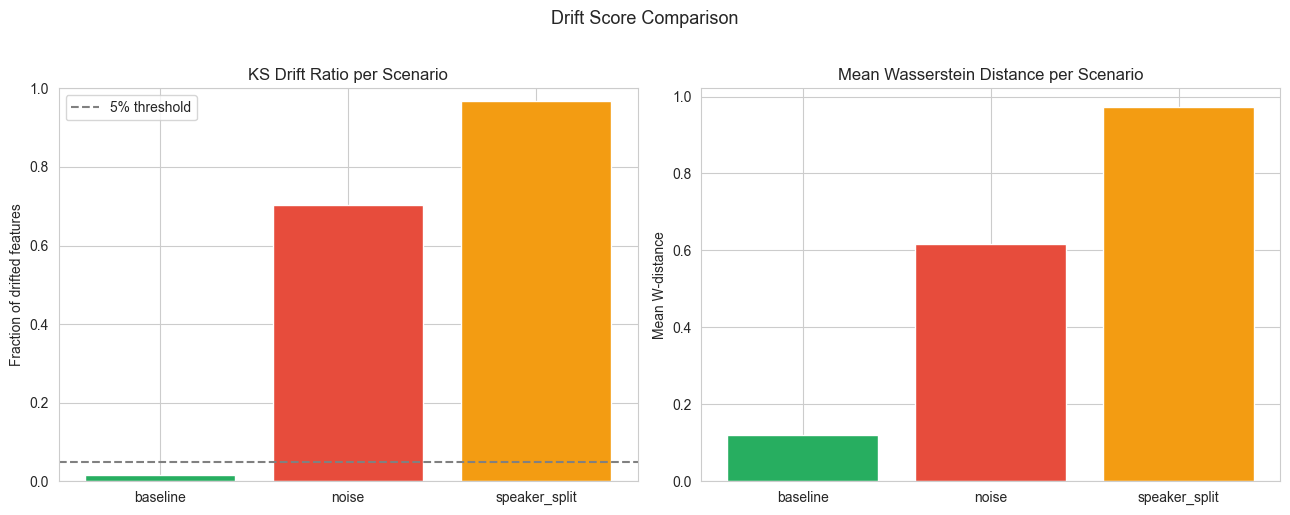

In [3]:
scores_df = pd.read_csv(EXPORTS_DIR / 'drift_scores.csv')
latest    = scores_df.drop_duplicates('scenario', keep='last')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scenario_colors = {'baseline': '#27ae60', 'noise': '#e74c3c', 'speaker_split': '#f39c12'}
colors = [scenario_colors[s] for s in latest['scenario']]

# KS drift ratio
axes[0].bar(latest['scenario'], latest['ks_drift_ratio'], color=colors, edgecolor='white')
axes[0].axhline(0.05, color='gray', linestyle='--', label='5% threshold')
axes[0].set_title('KS Drift Ratio per Scenario')
axes[0].set_ylabel('Fraction of drifted features')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Mean Wasserstein distance
axes[1].bar(latest['scenario'], latest['mean_wasserstein'], color=colors, edgecolor='white')
axes[1].set_title('Mean Wasserstein Distance per Scenario')
axes[1].set_ylabel('Mean W-distance')

plt.suptitle('Drift Score Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'drift_scenario_comparison.png', dpi=120)
plt.show()

## 3. Per-Feature Drift Heatmap (Noise vs Baseline)

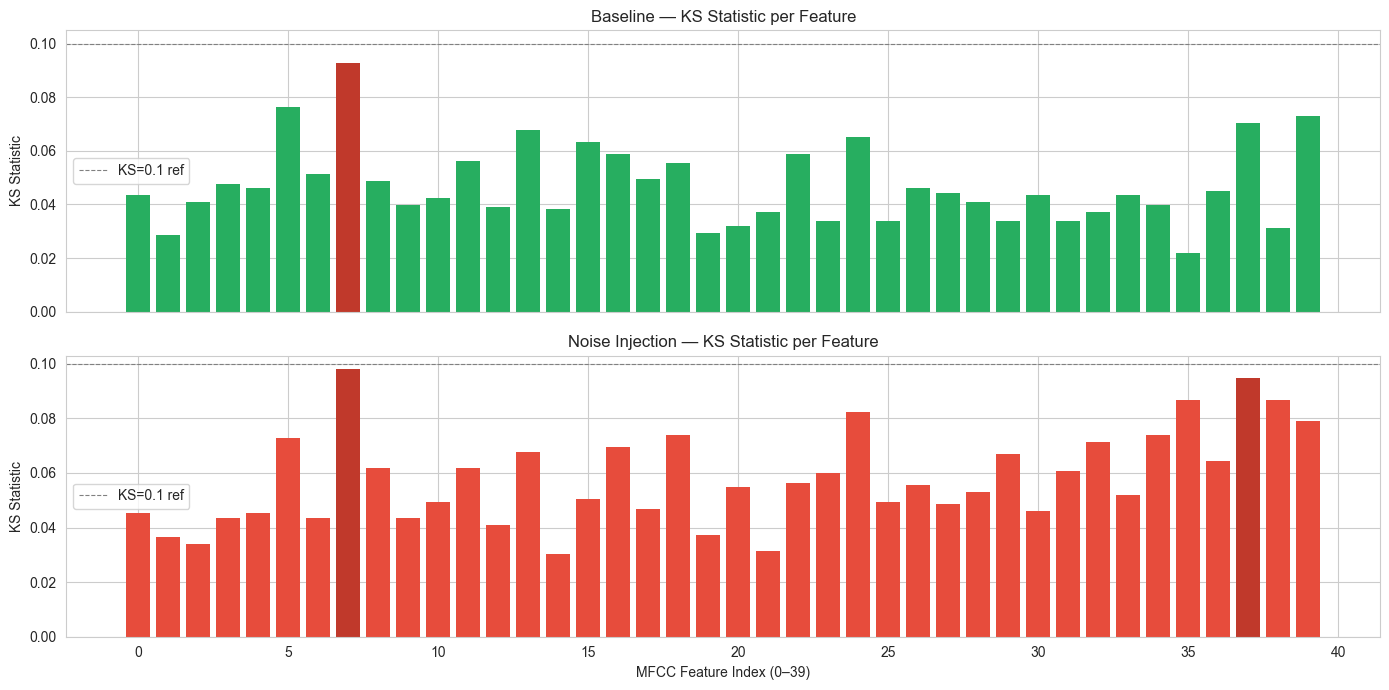

In [4]:
import glob

def load_latest_report(scenario: str) -> pd.DataFrame:
    files = sorted(DRIFT_DIR.glob(f'drift_report_{scenario}_*.csv'))
    return pd.read_csv(files[-1]) if files else None

baseline_report = load_latest_report('baseline')
noise_report    = load_latest_report('noise')

# Show first 40 MFCC features (most interpretable)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, report, title, color in [
    (axes[0], baseline_report, 'Baseline — KS Statistic per Feature', '#27ae60'),
    (axes[1], noise_report,    'Noise Injection — KS Statistic per Feature', '#e74c3c'),
]:
    data = report.head(40)
    bar_colors = [color if not d else '#c0392b' for d in data['ks_drift']]
    ax.bar(range(40), data['ks_statistic'], color=bar_colors, edgecolor='none')
    ax.axhline(0.1, color='gray', linestyle='--', linewidth=0.8, label='KS=0.1 ref')
    ax.set_title(title)
    ax.set_ylabel('KS Statistic')
    ax.legend()

axes[1].set_xlabel('MFCC Feature Index (0–39)')
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'drift_feature_ks_comparison.png', dpi=120)
plt.show()

## 4. Feature Distribution Shift (Top Drifted Features)

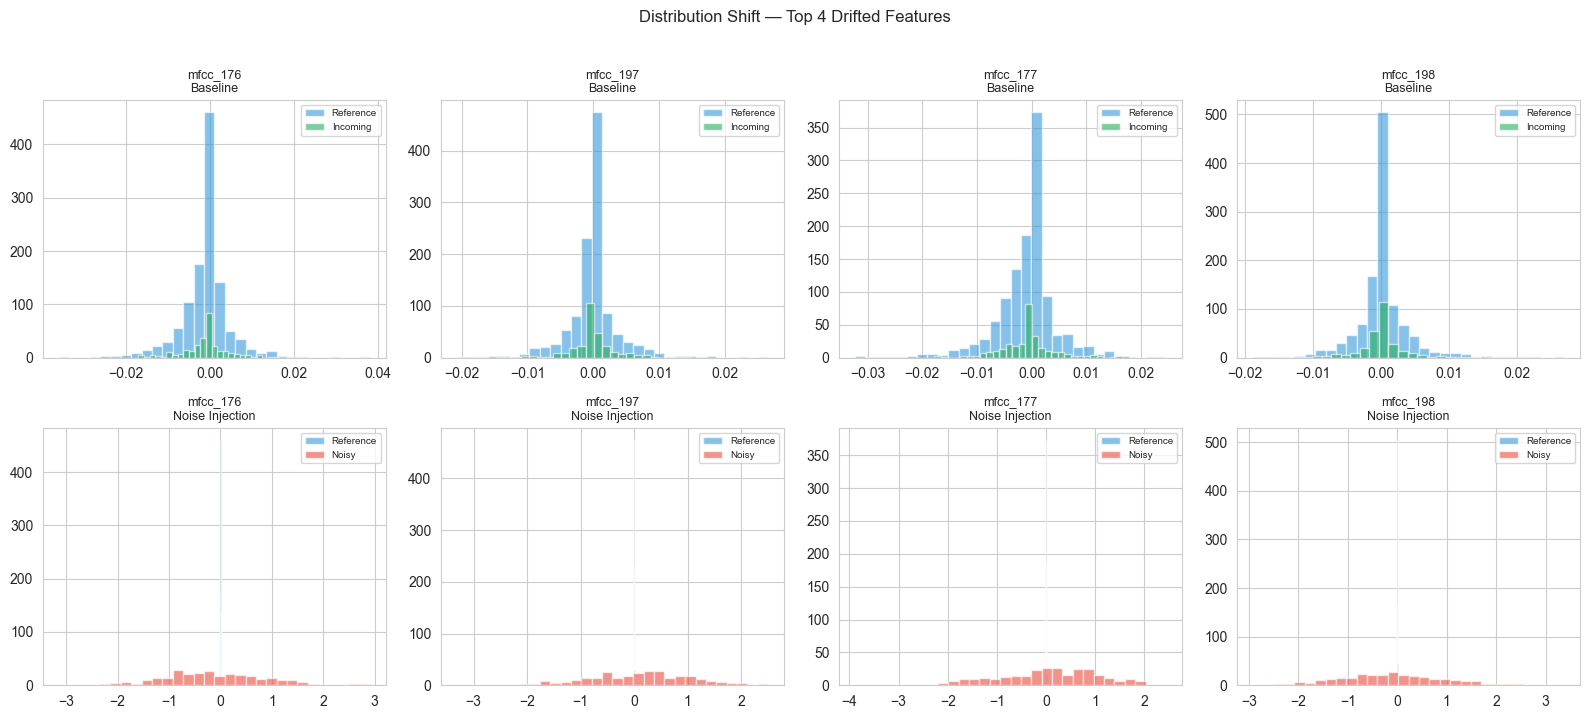

In [5]:
from src.drift_detection import scenario_baseline, scenario_noise

X        = np.load(FEATURES_DIR / 'mfcc_features.npy')
metadata = pd.read_csv(FEATURES_DIR / 'metadata.csv')

X_ref_b, X_inc_b, _ = scenario_baseline(X, metadata)
X_ref_n, X_inc_n, _ = scenario_noise(X, metadata, noise_std=1.0)

# Pick top 4 most drifted features from noise scenario
top_feats = noise_report.nlargest(4, 'ks_statistic')['feature'].tolist()
top_idx   = [int(f.split('_')[1]) for f in top_feats]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for col, (feat_name, feat_idx) in enumerate(zip(top_feats, top_idx)):
    # Baseline row
    axes[0][col].hist(X_ref_b[:, feat_idx], bins=30, alpha=0.6,
                      color='#3498db', label='Reference')
    axes[0][col].hist(X_inc_b[:, feat_idx], bins=30, alpha=0.6,
                      color='#27ae60', label='Incoming')
    axes[0][col].set_title(f'{feat_name}\nBaseline', fontsize=9)
    axes[0][col].legend(fontsize=7)

    # Noise row
    axes[1][col].hist(X_ref_n[:, feat_idx], bins=30, alpha=0.6,
                      color='#3498db', label='Reference')
    axes[1][col].hist(X_inc_n[:, feat_idx], bins=30, alpha=0.6,
                      color='#e74c3c', label='Noisy')
    axes[1][col].set_title(f'{feat_name}\nNoise Injection', fontsize=9)
    axes[1][col].legend(fontsize=7)

plt.suptitle('Distribution Shift — Top 4 Drifted Features', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'drift_distribution_shift.png', dpi=120)
plt.show()

## 5. Drift vs Model Performance Correlation

baseline         Acc=0.6181  F1=0.5986  Drift=1.7%
noise            Acc=0.1354  F1=0.1137  Drift=70.4%
speaker_split    Acc=0.9167  F1=0.9167  Drift=96.7%


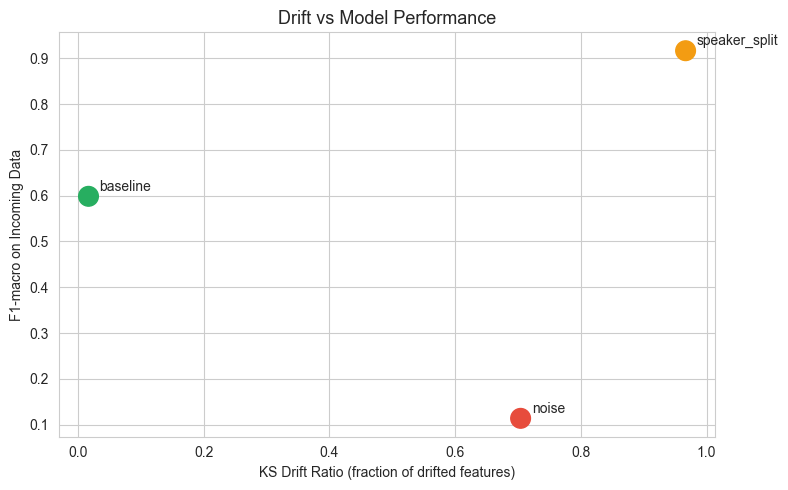

In [6]:
import joblib
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from src.drift_detection import scenario_baseline, scenario_noise, scenario_speaker_split

model  = joblib.load('../models/mlp_model.joblib')
scaler = joblib.load('../models/scaler.joblib')
y      = np.load(FEATURES_DIR / 'labels.npy')

scenario_fns = {
    'baseline':      lambda: scenario_baseline(X, metadata),
    'noise':         lambda: scenario_noise(X, metadata, noise_std=1.0),
    'speaker_split': lambda: scenario_speaker_split(X, metadata),
}

perf_rows = []
for name, fn in scenario_fns.items():
    X_ref, X_inc, inc_meta = fn()

    # Get true labels for incoming data
    if name == 'baseline':
        test_mask = metadata['split'] == 'test'
        y_true = y[test_mask.values]
    elif name == 'speaker_split':
        female_mask = metadata['gender'] == 'female'
        y_true = y[female_mask.values]
    else:  # noise — same indices as test
        test_mask = metadata['split'] == 'test'
        y_true = y[test_mask.values]

    X_inc_s = scaler.transform(X_inc)
    y_pred  = model.predict(X_inc_s)
    acc     = accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred, average='macro')
    drift   = results[name]['ks_drift_ratio']

    perf_rows.append({'scenario': name, 'accuracy': acc, 'f1_macro': f1,
                      'ks_drift_ratio': drift})
    print(f"{name:<15}  Acc={acc:.4f}  F1={f1:.4f}  Drift={drift:.1%}")

perf_df = pd.DataFrame(perf_rows)

# Save drift-vs-performance table for Power BI
perf_df.to_csv(EXPORTS_DIR / 'drift_vs_performance.csv', index=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = [scenario_colors[s] for s in perf_df['scenario']]
scatter = ax.scatter(perf_df['ks_drift_ratio'], perf_df['f1_macro'],
                     c=colors, s=200, zorder=5)
for _, row in perf_df.iterrows():
    ax.annotate(row['scenario'], (row['ks_drift_ratio'], row['f1_macro']),
                textcoords='offset points', xytext=(8, 4), fontsize=10)
ax.set_xlabel('KS Drift Ratio (fraction of drifted features)')
ax.set_ylabel('F1-macro on Incoming Data')
ax.set_title('Drift vs Model Performance', fontsize=13)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'drift_vs_performance.png', dpi=120)
plt.show()

## 6. Drift Alert Summary

In [7]:
alert_threshold = 0.3  # from config: drift_detection.drift_score

print('=' * 50)
print('           DRIFT ALERT SUMMARY')
print('=' * 50)
for _, row in perf_df.iterrows():
    alert = '🚨 ALERT' if row['ks_drift_ratio'] > alert_threshold else '✅ OK'
    print(f"  {row['scenario']:<15}  Drift={row['ks_drift_ratio']:.1%}  "
          f"F1={row['f1_macro']:.4f}  {alert}")
print('=' * 50)

           DRIFT ALERT SUMMARY
  baseline         Drift=1.7%  F1=0.5986  ✅ OK
  noise            Drift=70.4%  F1=0.1137  🚨 ALERT
  speaker_split    Drift=96.7%  F1=0.9167  🚨 ALERT
